# Generative AI models comparison: ECG dataset

### Setup

In [1]:
!pip install -q wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 82.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.


In [2]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/results/notebook'
%cd "{PROJECT_PATH}"

BASE_DIR = os.path.abspath("..")
DATA_DIR = os.path.join(BASE_DIR, "data")
IMAGE_DIR = os.path.join(BASE_DIR, "saved_images")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/results/notebook

[INFO] Running on device: cpu



In [3]:
from utils import (
    load_data,
    extract_generated_functions,
    save_image,
)

from utils_plots import (
    plot_function_grid,
    plot_forward_processes,
    plot_generation_processes,
)

from metrics import (
    compute_dataset_metrics,
    plot_ecg_metric_grid,
)

### Load saved results

In [4]:
# data_train
keys = ["data", "data_eps", "seed", "x_inf", "x_sup", "sampling_rate"]
data_train, data_eps, seed, x_inf, x_sup, sampling_rate = load_data(DATA_DIR, "dataset_samples.pt", keys)
axis_x = torch.linspace(x_inf, x_sup, data_train.shape[-1])
print(data_train.shape)

torch.Size([9246, 1, 500])


In [5]:
# flow matching

# interpolation process
keys = ["data", "t_0", "t_end", "t_eps"]
flow_interpolation, t_0, t_end, t_eps_flow= load_data(DATA_DIR, "forward_flow_interpolation.pt", keys)
print(flow_interpolation.shape)

# generation process
keys = ["data", "seed"]
flow_generation, seed = load_data(DATA_DIR, "generated_flow_samples.pt", keys)
print(flow_generation.shape)

torch.Size([9246, 100, 1, 500])
torch.Size([9246, 100, 1, 500])


In [6]:
# isotropic diffusion

# forward process
keys = ["data", "t_0", "t_end", "t_eps"]
forward_diffusion, _, _, t_eps_diffusion= load_data(DATA_DIR, "forward_diffusion_process.pt", keys)
print(forward_diffusion.shape)

# generation process
keys = ["data", "seed"]
diffusion_generation, seed = load_data(DATA_DIR, "generated_diffusion_samples.pt", keys)
print(diffusion_generation.shape)

torch.Size([9246, 100, 1, 500])
torch.Size([9246, 101, 1, 500])


### Extract generated functions

In [7]:
# flow matching

flow_samples = extract_generated_functions(
    generated_samples=flow_generation,
    denorm=True,
    data_mean=data_train.mean(),
    data_std=data_train.std(),
    data_eps=data_eps,
)

print(flow_samples.shape)

# flow matching

diffusion_samples = extract_generated_functions(
    generated_samples=diffusion_generation,
    denorm=True,
    data_mean=data_train.mean(),
    data_std=data_train.std(),
    data_eps=data_eps,
)

print(diffusion_samples.shape)

torch.Size([9246, 1, 500])
torch.Size([9246, 1, 500])


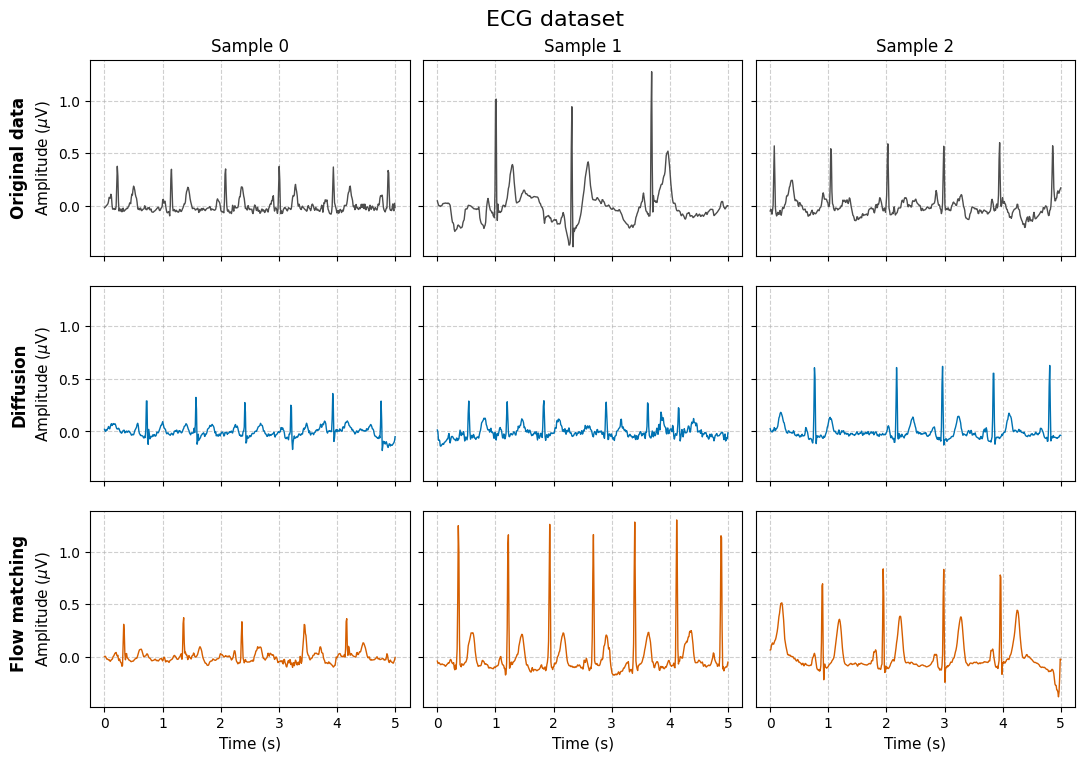

In [8]:
MODEL_COLORS = {
    "Original data": "#4D4D4D",
    "Diffusion": "#0072B2",
    "Flow matching": "#D55E00",
}


fig_samples = plot_function_grid(
    {"Original data": data_train, "Diffusion": diffusion_samples, "Flow matching": flow_samples},
    axis_x=axis_x, seed=seed, mode="separated", n_samples=3, suptitle="ECG dataset", colors=MODEL_COLORS,
)

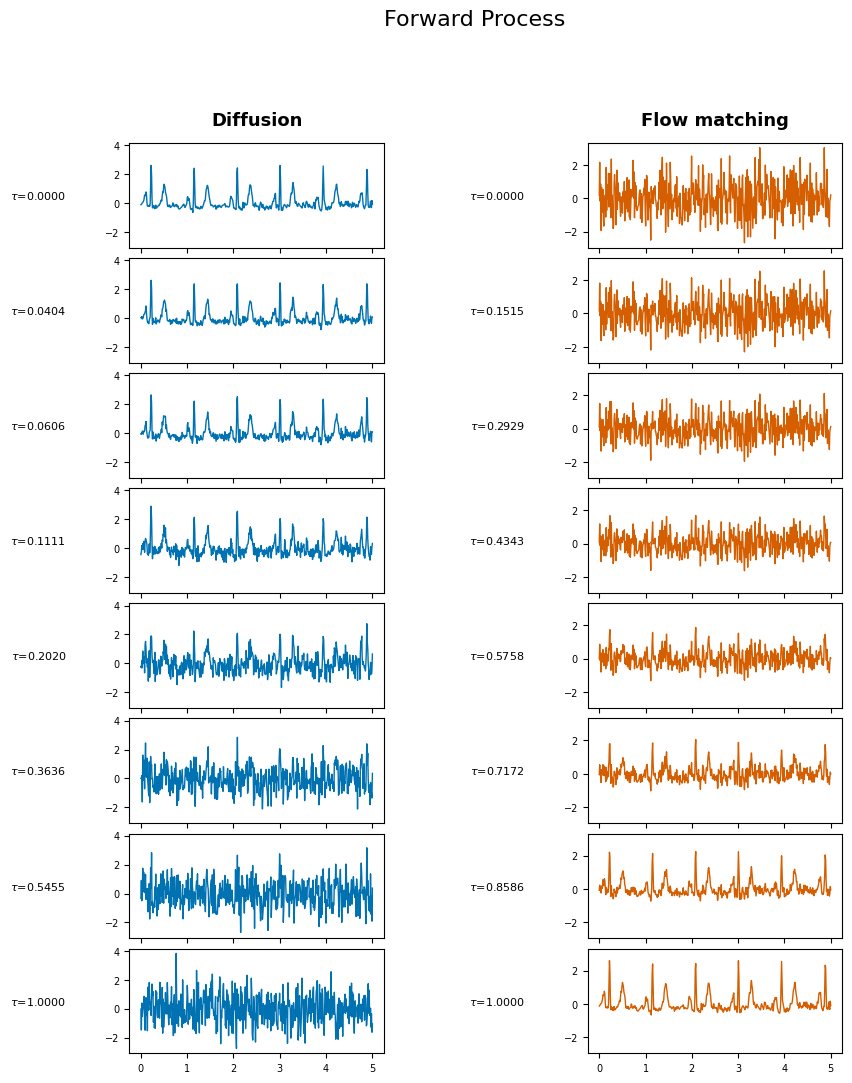

In [9]:
fig_forward = plot_forward_processes(
    forward_diffusion,
    flow_interpolation,
    axis_x,
    t_start_diffusion=t_0,
    t_end_diffusion=t_end,
    t_start_flow=t_0,
    t_end_flow=t_end,
    num_steps=8, n_samples=1, cell_size=(6.0, 2.0),
    suptitle="Forward Process", colors=MODEL_COLORS,
)

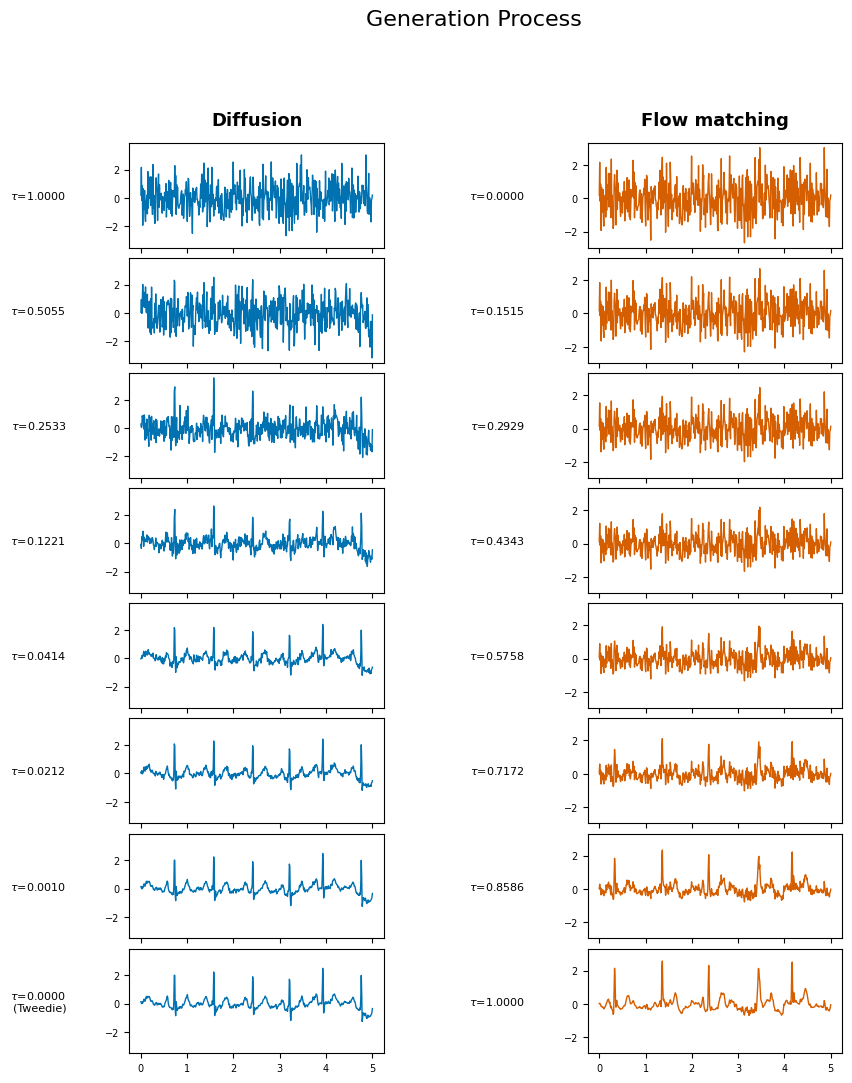

In [10]:
fig_generation = plot_generation_processes(
    diffusion_generation,
    flow_generation,
    axis_x,
    t_start_diffusion=t_end,
    t_end_diffusion=t_eps_diffusion,
    t_start_flow=t_0,
    t_end_flow=t_end,
    num_steps=8, n_samples=1, cell_size=(6.0, 2.0),
    suptitle="Generation Process", colors=MODEL_COLORS,
)

### Metrics comparison

In [11]:
original_metrics_df = compute_dataset_metrics(data_train, fs=sampling_rate)
diffusion_metrics_df = compute_dataset_metrics(diffusion_samples, fs=sampling_rate)
flow_metrics_df = compute_dataset_metrics(flow_samples, fs=sampling_rate)

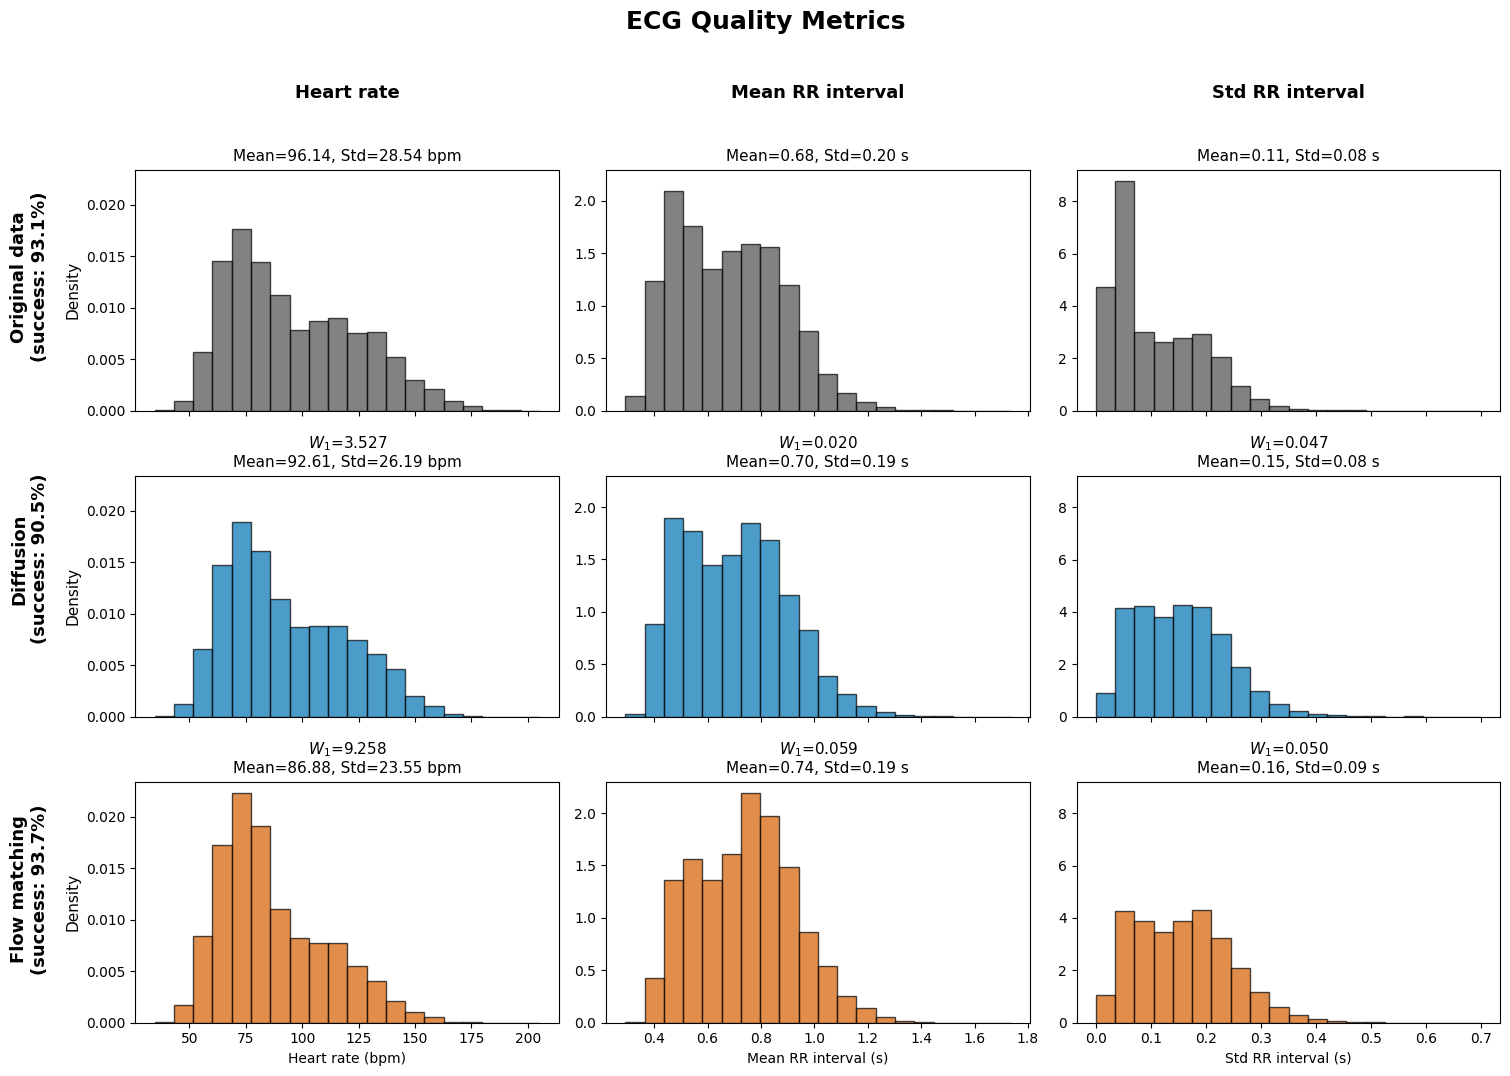

In [12]:
models = {
    "Original data": {"df": original_metrics_df[original_metrics_df["success"]], "success_rate": original_metrics_df["success"].mean()},
    "Diffusion": {"df": diffusion_metrics_df[diffusion_metrics_df["success"]], "success_rate": diffusion_metrics_df["success"].mean()},
    "Flow matching": {"df": flow_metrics_df[flow_metrics_df["success"]], "success_rate": flow_metrics_df["success"].mean()},
}

metric_cols = [
    ("hr_bpm", "Heart rate", "bpm"),
    ("rr_mean", "Mean RR interval", "s"),
    ("rr_std", "Std RR interval", "s"),
]

colors = {
    "Original data": "#4D4D4D",
    "Diffusion": "#0072B2",
    "Flow matching": "#D55E00",
}

fig_parameters = plot_ecg_metric_grid(models, metric_cols, colors=MODEL_COLORS)

In [13]:
save_image(fig_samples, IMAGE_DIR, "fig_ecg_samples.pdf")
save_image(fig_forward, IMAGE_DIR, "fig_ecg_forward.pdf")
save_image(fig_generation, IMAGE_DIR, "fig_ecg_generation.pdf")
save_image(fig_parameters, IMAGE_DIR, "fig_ecg_parameters.pdf")


Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/results/saved_images/fig_ecg_samples.pdf
Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/results/saved_images/fig_ecg_forward.pdf
Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/results/saved_images/fig_ecg_generation.pdf
Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/results/saved_images/fig_ecg_parameters.pdf


PosixPath('/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 0/results/saved_images/fig_ecg_parameters.pdf')